In [1]:
import jax 
import jax.numpy as jnp
import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding, SinusoidalEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

import matplotlib.pyplot as plt

from functools import partial

In [2]:
jax.devices()

I0000 00:00:1700660866.146755   14218 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [3]:
from sbibm import get_task

task = get_task("gaussian_linear")
prior = task.get_prior_dist()
simulator = task.get_simulator()

thetas = prior.sample((100000,))
xs = simulator(thetas)

thetas = jnp.array(thetas)
xs = jnp.array(xs)


2023-11-22 14:48:05.980654: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
data = jnp.hstack([thetas, xs])
data = data[..., None]
num_nodes = data.shape[-2]
node_id = jnp.arange(num_nodes)

theta_dim = thetas.shape[-1]
x_dim = xs.shape[-1]

In [5]:

def model(t,data, data_id, condition_mask = None):
    dim = 10
    tokenizer = ScalarTokenizer(dim, len(node_id))
    time_embeder = SinusoidalEmbedding(dim)
    
    # Embedding
    tokens = tokenizer(data_id,data)
    time = time_embeder(t[..., None])
    
    # Conditioning
    if condition_mask is not None:
        condition_token = hk.get_parameter("condition_token", shape=[1,1,dim], init=hk.initializers.RandomNormal(0.01))
        condition_mask = condition_mask.reshape(-1,data.shape[-2],1)
        tokens = tokens + condition_mask * condition_token
    
    # Forward pass 
    model = Transformer(num_heads=4, num_layers=4, attn_size=dim, widening_factor=20)
    h = model(tokens, context=time)
    out = hk.Linear(1)(h)
    return out

init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
params = init_fn(jax.random.PRNGKey(0), jnp.zeros(data[:10].shape[0],),data[:10], node_id,jnp.ones((10,theta_dim+x_dim)))
out = model_fn(params, jnp.zeros(data[:10].shape[0],),data[:10], node_id)


In [6]:
from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

In [7]:
p0 = Independent(Empirical(data), 2)
beta_max = 20.
beta_min = 0.1
sde = VPSDE(p0, beta_max=beta_max, beta_min=beta_min)
t = jnp.linspace(0,1,200)

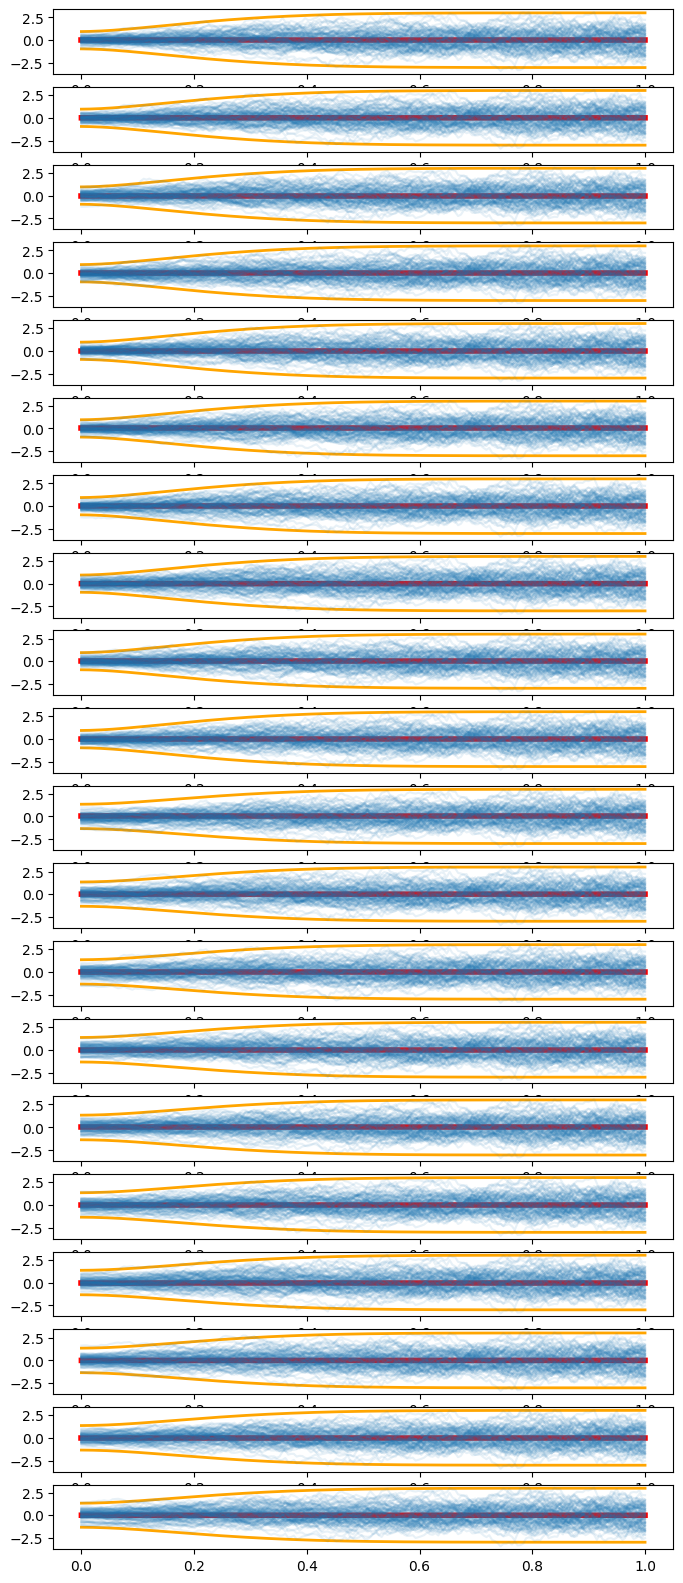

In [8]:
mean = sde.mean(t)
std = sde.stddev(t)
forward_samples = sde.sample(jax.random.PRNGKey(0), t, sample_shape=(100,))

fig, axes = plt.subplots(theta_dim+x_dim,1, figsize=(8, theta_dim+x_dim))
for i in range(len(axes)):
    _ = axes[i].plot(t, mean[:,i,0].T, lw=4, color="red")
    _ = axes[i].plot(t, mean[:,i,0].T + 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, mean[:,i,0].T - 3*std[:,i,0].T, lw=2, color="orange")
    _ = axes[i].plot(t, forward_samples[...,i,0].T, color="C0", alpha=0.1)


In [9]:
# VPSDE 
T = 1.
T_min = 1e-6

def weight_fn(t):
    t = t.reshape(-1,1,1)
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-5

In [10]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [11]:
def loss_fn(params, key, data, node_id):
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    condition_mask = jax.random.choice(key_condition, jnp.stack([jnp.array([0]*(theta_dim + x_dim)), jnp.array([0]*theta_dim + [1]*x_dim)]), shape=(data.shape[0],), p = jnp.array([0.,1.]))
    loss = denoising_score_matching_loss(params, key_loss, times, data, condition_mask, node_id, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [12]:
num_epochs = 1000
batch_size = 800
num_devices = jax.device_count()
batch_size_per_device = batch_size // num_devices
num_steps = data.shape[0] // batch_size + 1

In [13]:
replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

In [14]:

key = jax.random.PRNGKey(1)
for j in range(num_epochs):
    l = 0
    for i in range(num_steps):
        key, key_batch, key_update = jax.random.split(key, 3)
        data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0)
        node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch)
        l += loss[0] /num_steps
    if (j % 50) == 0:     
        print(l)

2.8266056
0.92565626
0.930076
0.91795605
0.91489464
0.91248953
0.90529376
0.9046683
0.9093749
0.9152391
0.89690024
0.91150516
0.90976477
0.9111633
0.9003151
0.91170186
0.90028894
0.89186484
0.9081529
0.9105123


In [15]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [16]:

def sde_fn(condition_mask):

    def score_fn(t, x):
        x_embed = x.reshape(1, -1,1)
        score = model_fn(params, jnp.atleast_1d(t), x_embed, node_id, condition_mask.reshape(1,-1,1))
        return score.reshape(x.shape)

    def drift_backwards(t, x):
        t = (1- t)
        score = score_fn(t, x)
        drift = sde.drift(t, x) - sde.diffusion(t, x)**2 * score 
        drift = -drift * (1-condition_mask.reshape(x.shape))
        #print(drift.shape)
        return drift

    def diffusion_backwards(t, x):
        t = (1-t)
        diffusion = sde.diffusion(t, x) 
        return diffusion * (1-condition_mask.reshape(x.shape))

    return drift_backwards, diffusion_backwards

In [17]:
condition_value = data[0].reshape(1, -1 ,1)
condition_mask = jnp.array([0]*10 + [1]*10).reshape(1,-1,1)

In [18]:
from probjax.utils.sdeint import sdeint

In [19]:
def sample_fn(key, shape, x_o, condition_mask):
    key1, key2 = jax.random.split(key, 2)
    drift, diffusion = sde_fn(condition_mask)
    x_T = jax.random.normal(key1, shape + (len(node_id),)) #* marginal_std(jnp.zeros((1,)), 1.) + marginal_mean(jnp.zeros((1,)), 1.)
    condition_mask = condition_mask.reshape(1, -1, 1)
    x_T = x_T[..., None] * (1-condition_mask) + x_o * condition_mask
    x_T = x_T.reshape(shape + (theta_dim+x_dim,))
    keys = jax.random.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., 1-T_min, 400))
    return ys

In [20]:
from sbi.analysis.sbc import c2st
import torch
import numpy as np

In [21]:

c2sts = []
for i in range(1,11):
    x_o = task.get_observation(i)
    samples_post = task.get_reference_posterior_samples(i)
    
    x_o = jnp.array(x_o)
    condition_value = condition_value.at[:,10:,0].set(x_o)
    samples_est = sample_fn(jax.random.PRNGKey(i), (10000,), condition_value, condition_mask)
    samples_est = samples_est[:, -1,:10]
    print(samples_est.shape)
    metric = c2st(torch.tensor(np.array(samples_est)), samples_post)
    print(metric)

(10000, 10)
tensor([0.5221])
(10000, 10)
tensor([0.5221])
(10000, 10)
tensor([0.5282])
(10000, 10)
tensor([0.5421])
(10000, 10)
tensor([0.5281])
(10000, 10)
tensor([0.5327])
(10000, 10)
tensor([0.5338])
(10000, 10)
tensor([0.5360])
(10000, 10)
tensor([0.5215])
(10000, 10)
tensor([0.5333])
